# Lab 4.1: Xây dựng ANN với Tensorflow dự đoán Churn Customer
**Người thực hiện:** Đào Minh Trí
**Đề tài:** Dự đoán khả năng rời bỏ dịch vụ của khách hàng (Customer Churn) bằng mạng nơ-ron nhân tạo (Artificial Neural Network) sử dụng thư viện TensorFlow và Keras.

---
### Các bước thực hiện theo yêu cầu:
1. Kết nối Google Drive và cài đặt/gọi thư viện.
2. Tải dữ liệu và cấu hình đường dẫn đọc dữ liệu từ Google Drive/Local.
3. Xây dựng mô hình mạng nơ-ron nhân tạo (ANN).
4. Huấn luyện (đào tạo) mô hình.
5. Kiểm tra và đánh giá hiệu năng mô hình.
6. Sử dụng mô hình dự đoán.
7. Hiển thị kết quả trực quan (đồ thị Loss/Accuracy và Confusion Matrix).


## 1. Kết nối Google Drive, Cài đặt và Gọi thư viện

In [1]:
# 1. Kết nối Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Kết nối Google Drive thành công!")
except ImportError:
    print("Không phát hiện môi trường Google Colab. Bỏ qua kết nối Google Drive.")


Không phát hiện môi trường Google Colab. Bỏ qua kết nối Google Drive.


In [2]:
# 2. Cài đặt các thư viện cần thiết
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn kagglehub


zsh:1: command not found: pip


In [3]:
# 3. Gọi các thư viện
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print("TensorFlow Version:", tf.__version__)


/Users/huythanh/Code/TriMT/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow Version: 2.20.0


## 2. Tải dữ liệu và Thiết lập đường dẫn đọc dữ liệu

In [4]:
# 4. Tải dữ liệu từ Kaggle
import kagglehub
try:
    path = kagglehub.dataset_download("aakash50897/churn-modellingcsv")
    print("Đường dẫn tải dữ liệu về máy:", path)
except Exception as e:
    print("Lỗi khi tải dữ liệu:", e)


Đường dẫn tải dữ liệu về máy: /Users/huythanh/.cache/kagglehub/datasets/aakash50897/churn-modellingcsv/versions/1


In [5]:
# 5. Thiết lập đường dẫn và đọc dữ liệu từ Google Drive (hoặc file local)
drive_path = '/content/drive/MyDrive/Churn_Modelling.csv'
local_path = 'Churn_Modelling.csv'

# Kiểm tra đường dẫn nào tồn tại để đọc dữ liệu
if os.path.exists(drive_path):
    csv_path = drive_path
    print(f"Đọc dữ liệu từ Google Drive: {csv_path}")
else:
    # Nếu chạy local hoặc chưa upload lên Drive, copy file đã tải về thư mục hiện tại để đọc
    if not os.path.exists(local_path):
        import shutil
        source_file = os.path.join(path, 'Churn_Modelling.csv')
        if os.path.exists(source_file):
            shutil.copy(source_file, local_path)
    csv_path = local_path
    print(f"Đọc dữ liệu từ file local: {csv_path}")

# Đọc dữ liệu vào DataFrame
dataset = pd.read_csv(csv_path)
dataset.head()


Đọc dữ liệu từ file local: Churn_Modelling.csv


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Hiển thị thông tin tổng quan về tập dữ liệu
dataset.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


Tách các cột không cần thiết như `RowNumber`, `CustomerId`, `Surname` và lấy biến phụ thuộc `Exited` (biến đích biểu thị khách hàng rời đi hay ở lại).


In [7]:
X = dataset.drop(labels=['CustomerId', 'Surname', 'RowNumber', 'Exited'], axis=1)
y = dataset['Exited']
X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


Mã hóa các cột dạng phân loại (categorical variables) gồm `Geography` (Quốc gia) và `Gender` (Giới tính) sử dụng `LabelEncoder`.


In [8]:
# Khởi tạo và mã hóa cột Geography
label_geo = LabelEncoder()
X['Geography'] = label_geo.fit_transform(X['Geography'])

# Khởi tạo và mã hóa cột Gender
label_gender = LabelEncoder()
X['Gender'] = label_gender.fit_transform(X['Gender'])

X.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,0,0,42,2,0.00,1,1,1,101348.88
1,608,2,0,41,1,83807.86,1,0,1,112542.58
2,502,0,0,42,8,159660.80,3,1,0,113931.57
3,699,0,0,39,1,0.00,2,0,0,93826.63
4,850,2,0,43,2,125510.82,1,1,1,79084.10


Do quốc gia (`Geography`) có 3 nhóm giá trị, sau khi Label Encoding, ta thực hiện One-Hot Encoding sử dụng `pd.get_dummies` với tham số `drop_first=True` để tránh bẫy đa cộng tuyến (Dummy Variable Trap).


In [9]:
X = pd.get_dummies(X, drop_first=True, columns=['Geography'])
X.head()


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_1,Geography_2
0,619,0,42,2,0.00,1,1,1,101348.88,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,False,True


Chia tập dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%), phân tầng (stratify) dựa trên biến đích `y` để đảm bảo tỷ lệ nhãn cân đối.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)


Kích thước tập Train: (8000, 11)
Kích thước tập Test: (2000, 11)


Chuẩn hóa các đặc trưng (Feature Scaling) bằng `StandardScaler` để đưa các giá trị về cùng một phân phối chuẩn có trung bình là 0 và độ lệch chuẩn là 1, giúp mạng ANN hội tụ nhanh hơn.


In [11]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train[:3]


array([[-1.24021723, -1.09665089,  0.77986083,  0.35390313, -1.23451386,
        -0.90298067, -1.54963239, -1.03849022,  1.64099027, -0.57812007,
        -0.57504086],
       [ 0.75974873,  0.91186722, -0.27382717,  0.35390313,  0.2854211 ,
         0.81371262,  0.64531434,  0.96293637, -1.55587522,  1.72974448,
        -0.57504086],
       [-1.72725557, -1.09665089, -0.9443559 , -0.3390904 ,  0.85569573,
        -0.90298067,  0.64531434, -1.03849022,  1.1038111 , -0.57812007,
        -0.57504086]])

## 3. Xây dựng mô hình mạng ANN (Build ANN)
Khởi tạo mô hình mạng nơ-ron nhân tạo tuần tự (`Sequential`) bao gồm:
- **Lớp đầu tiên (Input & Hidden Layer 1)**: Số nút bằng kích thước đầu vào (`X.shape[1]`), hàm kích hoạt (activation function) là `relu`.
- **Lớp ẩn thứ hai (Hidden Layer 2)**: 128 nút, hàm kích hoạt `relu`.
- **Lớp đầu ra (Output Layer)**: 1 nút (do dự đoán nhị phân), hàm kích hoạt `sigmoid` để đưa ra xác suất rời bỏ dịch vụ.


In [12]:
model = Sequential()
model.add(Dense(X.shape[1], activation='relu', input_dim=X.shape[1]))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()


/Users/huythanh/Code/TriMT/.venv/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,797 (7.02 KB)

 Trainable params: 1,797 (7.02 KB)

 Non-trainable params: 0 (0.00 B)

Biên dịch (Compile) mô hình:
- Thuật toán tối ưu (Optimizer): `adam`
- Hàm mất mát (Loss function): `binary_crossentropy`
- Chỉ số đánh giá (Metrics): `accuracy`


In [13]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


## 4. Đào tạo mô hình (Train/Fit ANN)
Huấn luyện mô hình trên tập huấn luyện (`X_train`) trong 10 epoch, batch size bằng 10, phân tách thêm 10% tập validation để theo dõi quá trình học tập.


In [14]:
history = model.fit(
    X_train, 
    y_train.to_numpy(), 
    batch_size=10, 
    epochs=10, 
    validation_split=0.1, 
    verbose=1
)


Epoch 1/10


  1/720 ━━━━━━━━━━━━━━━━━━━━ 3:10 266ms/step - accuracy: 0.4000 - loss: 0.7337

166/720 ━━━━━━━━━━━━━━━━━━━━ 0s 303us/step - accuracy: 0.7505 - loss: 0.5827  

353/720 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.7684 - loss: 0.5457

546/720 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.7777 - loss: 0.5243

...

  1/720 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9000 - loss: 0.1943

194/720 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8709 - loss: 0.3113

389/720 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step - accuracy: 0.8704 - loss: 0.3168

584/720 ━━━━━━━━━━━━━━━━━━━━ 0s 258us/step - accuracy: 0.8690 - loss: 0.3205

720/720 ━━━━━━━━━━━━━━━━━━━━ 0s 297us/step - accuracy: 0.8680 - loss: 0.3229 - val_accuracy: 0.8612 - val_loss: 0.3347


## 5. Kiểm tra và Sử dụng mô hình để dự đoán (Evaluation & Prediction)
Sử dụng mô hình để dự đoán nhãn lớp cho tập kiểm tra (`X_test`).


In [15]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype("int32")


 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 343us/step


In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test.to_numpy())
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


 1/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8125 - loss: 0.3407

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.8590 - loss: 0.3522


Test Loss: 0.3452
Test Accuracy: 0.8610


In [17]:
# Tạo ma trận nhầm lẫn và hiển thị các chỉ số đánh giá
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("Accuracy Score:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[1549   44]
 [ 234  173]]
Accuracy Score: 0.861

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.80      0.43      0.55       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



## 6. Hiển thị kết quả trực quan (Visualization)
Vẽ đồ thị lịch sử huấn luyện (Loss và Accuracy qua từng epoch) và Heatmap của Ma trận nhầm lẫn.


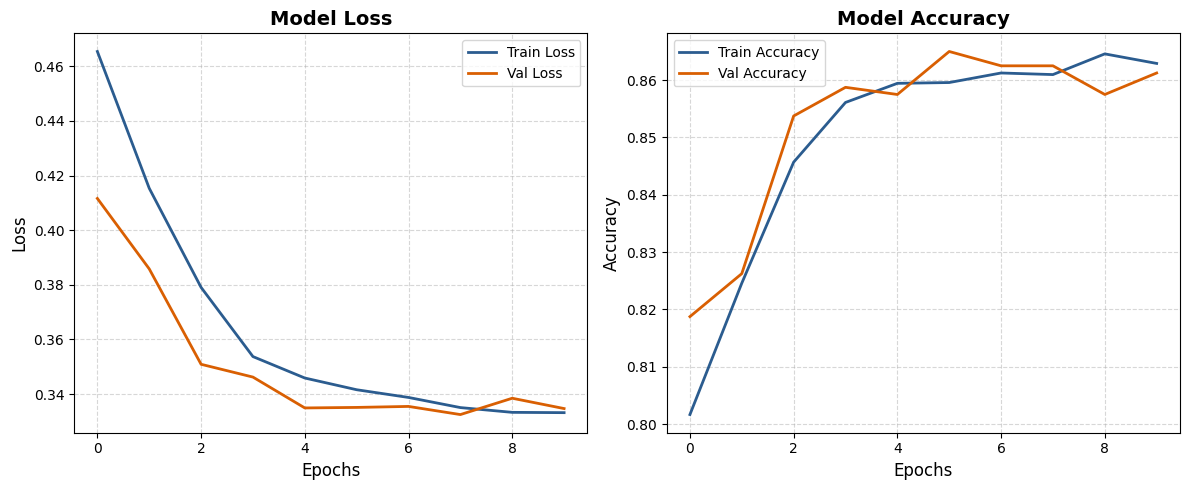

In [18]:
plt.figure(figsize=(12, 5))

# Đồ thị Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#2b5c8f', lw=2)
if 'val_loss' in history.history:
    plt.plot(history.history['val_loss'], label='Val Loss', color='#d95f02', lw=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Đồ thị Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='#2b5c8f', lw=2)
if 'val_accuracy' in history.history:
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='#d95f02', lw=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()


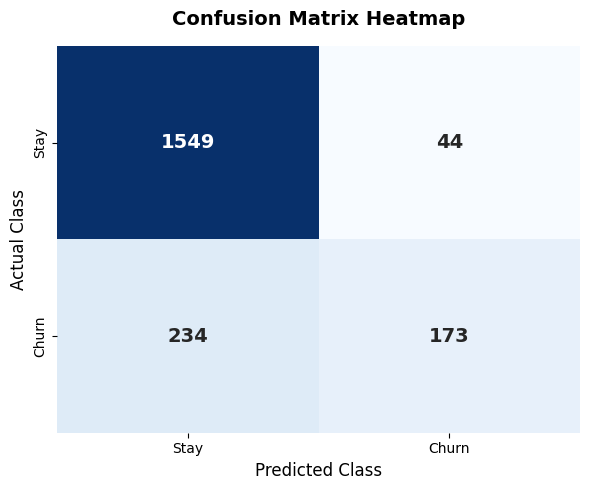

In [19]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'],
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Actual Class', fontsize=12)
		
plt.xlabel('Predicted Class', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
